In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.amp import autocast, GradScaler
import numpy as np
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.datasets import ImageFolder
from tqdm import tqdm

In [2]:
torch.backends.cudnn.deterministic = True

In [ ]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((96,96)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((96,96))
])

In [4]:
train_dataset = ImageFolder(
    root="/kaggle/input/xbd-buildings/building_dataset/train",
    transform=train_transform
)

test_dataset = ImageFolder(
    root="/kaggle/input/xbd-buildings/building_dataset/test",
    transform=test_transform
)

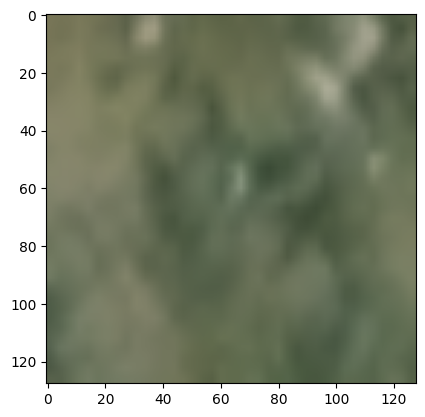

In [5]:
plt.imshow(test_dataset[1002][0].permute(1,2,0))

In [6]:
num_workers = 2
batch_size = 16
prefetch_factor = 16

In [7]:
train_dataloader = DataLoader(dataset=train_dataset,
                              shuffle=True,
                              batch_size=batch_size,
                              prefetch_factor=prefetch_factor,
                              num_workers=num_workers)

test_dataloader = DataLoader(dataset=test_dataset,
                              shuffle=True,
                              batch_size=batch_size,
                              prefetch_factor=prefetch_factor,
                              num_workers=num_workers)

In [8]:
imgs, labels = next(iter(train_dataloader))

In [9]:
imgs.shape, labels

(torch.Size([16, 3, 128, 128]),
 tensor([3, 3, 3, 3, 1, 0, 3, 3, 3, 2, 3, 3, 3, 3, 1, 0]))

In [10]:
scaler = GradScaler('cuda')

def train_step(model, optimizer, dataloader, loss_fn, epoch, device="cuda"):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for img, label in tqdm(dataloader):
        img, label = img.to(device), label.to(device)

        with autocast('cuda'):
            y_logits = model(img).squeeze(-1)

            if y_logits.isnan().any():
                print("⚠️ ABORT! NaN found in y_logit!")
                break

            loss = loss_fn(y_logits, label)
            batch_loss = loss.item()
            train_loss += batch_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        # scheduler.step()

        preds = y_logits.argmax(1)
        correct += (preds == label).sum().item()
        total += label.numel()

        del img, label, loss, y_logits

    avg_loss = train_loss / len(dataloader)
    avg_acc = 100 * correct / total

    return avg_loss, avg_acc


def test_step(model, dataloader, loss_fn, epoch, device="cuda"):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for img, label in tqdm(dataloader):
            img, label = img.to(device), label.to(device)


            with autocast('cuda'):
                y_logits = model(img).squeeze(-1)

                if y_logits.isnan().any():
                    print("⚠️ ABORT! NaN found in y_pred!")
                    break

                loss = loss_fn(y_logits, label)
                batch_loss = loss.item()
                test_loss += batch_loss

            preds = y_logits.argmax(1)
            correct += (preds == label).sum().item()
            total += label.numel()

            del img, label, loss, y_logits

    avg_loss = test_loss / len(dataloader)
    avg_acc = 100 * correct / total

    return avg_loss, avg_acc

In [ ]:
class DeepFakeModel(nn.Module):

    def __init__(self, dropout=0.15, negative_slope=0.1):
        super().__init__()
        # self.cnn = models.mobilenet_v2(weights='DEFAULT')
        # self.cnn.classifier = nn.Identity()

        mobile = models.mobilenet_v2(weights='DEFAULT')
        self.cnn = nn.Sequential(mobile.features[:12])

        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Linear(96,96),
            nn.LayerNorm(96),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.Dropout(dropout),

            nn.Linear(96, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.Dropout(dropout),

            nn.Linear(32,4)
        )

    def forward(self, x):
        encoded_output = self.cnn(x)
        logits = self.fc(encoded_output)
        return logits

In [ ]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = "cuda"

model = DeepFakeModel().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(params=model.parameters(),
                            lr=1e-4,
                            weight_decay=1e-3)

num_epochs = 20
steps_per_epoch = len(train_dataloader)
total_steps = num_epochs * steps_per_epoch

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    total_steps=total_steps,
    )

In [13]:
current = 0

start = 1 + current
epochs = num_epochs + current + 1

print(f"Running from {start} to {epochs-1}")

print("Ready to train!!")

for epoch in range(start, epochs):
    train_loss, train_acc = train_step(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epoch=epoch,
        dataloader=train_dataloader
    )

    test_loss, test_acc = test_step(
        model=model,
        loss_fn=loss_fn,
        epoch=epoch,
        dataloader=test_dataloader,
    )
    print(f'Epoch: {epoch} | Train Loss:{train_loss:.4f} | Train acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%')

    if epoch%1==0:
        checkpoint = {
            "model_state_dict" : model.state_dict(),
            "train_wer" : train_acc,
            "test_wer" : test_acc,
            "train_loss" : train_loss,
            "test_loss" : test_loss,
            "epoch" : epoch,
            "optimizer" : optimizer.state_dict(),
            "scheduler" : scheduler.state_dict()
        }
        torch.save(obj=checkpoint, f=f"XBD_Building_{epoch}_epochs_{test_acc:.2f}.pth")
        del checkpoint

Running from 1 to 20
Ready to train!!


100%|██████████| 2184/2184 [01:12<00:00, 30.05it/s]


Epoch: 1 | Train Loss:0.6465 | Train acc: 78.33% | Test Loss: 0.6139 | Test acc: 76.93%


100%|██████████| 2184/2184 [01:16<00:00, 28.49it/s]


Epoch: 2 | Train Loss:0.5416 | Train acc: 81.15% | Test Loss: 0.5457 | Test acc: 80.19%


...

Epoch: 17 | Train Loss:0.4013 | Train acc: 85.67% | Test Loss: 0.4287 | Test acc: 84.56%


100%|██████████| 2184/2184 [01:10<00:00, 30.82it/s]


Epoch: 18 | Train Loss:0.3974 | Train acc: 85.87% | Test Loss: 0.4351 | Test acc: 84.26%


 43%|████▎     | 5661/13102 [02:54<03:49, 32.46it/s]


KeyboardInterrupt: 

In [14]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))

              precision    recall  f1-score   support

   destroyed       0.75      0.80      0.77      2908
major_damage       0.52      0.60      0.56      3067
minor_damage       0.71      0.47      0.57      3847
   no_damage       0.91      0.93      0.92     25114

    accuracy                           0.84     34936
   macro avg       0.72      0.70      0.70     34936
weighted avg       0.84      0.84      0.84     34936



In [ ]:
# 128x128
#               precision    recall  f1-score   support

#    destroyed       0.75      0.80      0.77      2908
# major_damage       0.52      0.60      0.56      3067
# minor_damage       0.71      0.47      0.57      3847
#    no_damage       0.91      0.93      0.92     25114

#     accuracy                           0.84     34936
#    macro avg       0.72      0.70      0.70     34936
# weighted avg       0.84      0.84      0.84     34936


In [ ]:
# 96x96
#               precision    recall  f1-score   support

#    destroyed       0.74      0.79      0.76      2908
# major_damage       0.48      0.64      0.55      3067
# minor_damage       0.71      0.48      0.57      3847
#    no_damage       0.91      0.91      0.91     25114

#     accuracy                           0.83     34936
#    macro avg       0.71      0.70      0.70     34936
# weighted avg       0.84      0.83      0.83     34936